In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully")

Libraries loaded successfully


In [45]:
ev = pd.read_csv("../data/raw/ev_sessions.csv")
load = pd.read_csv("../data/raw/scaled_largehotel_profile.csv")

print("EV data shape:", ev.shape)
print("Load data shape:", load.shape)

EV data shape: (8530, 11)
Load data shape: (8760, 4)


In [46]:
ev.head()
# Preview of the data.

,day,vehicles_generated_day,session,assignment,connection_minute,full_minute,disconnection_minute,connection_timestamp,full_timestamp,disconnection_timestamp,energy_kwh
0,1,8,1,2,450,756,940,2023-01-01 07:30:00,2023-01-01 12:36:00,2023-01-01 15:40:00,7.0
1,1,8,2,2,541,680,1009,2023-01-01 09:01:00,2023-01-01 11:20:00,2023-01-01 16:49:00,9.0
2,1,8,3,1,423,965,1032,2023-01-01 07:03:00,2023-01-01 16:05:00,2023-01-01 17:12:00,14.0
3,1,8,4,2,572,744,966,2023-01-01 09:32:00,2023-01-01 12:24:00,2023-01-01 16:06:00,9.0
4,1,8,5,4,596,776,884,2023-01-01 09:56:00,2023-01-01 12:56:00,2023-01-01 14:44:00,6.0


In [47]:
load.head()
# Next Cell

,timestamp,base_profile_value,scaled_power_kw,scaled_energy_kwh
0,2023-01-01 00:00:00,0.000077,7.334217,7.334217
1,2023-01-01 01:00:00,0.000076,7.284518,7.284518
2,2023-01-01 02:00:00,0.000064,6.109935,6.109935
3,2023-01-01 03:00:00,0.000064,6.081038,6.081038
4,2023-01-01 04:00:00,0.000067,6.380343,6.380343


In [48]:
ev.shape

(8530, 11)

In [49]:
load.shape

(8760, 4)

In [50]:
ev.head()

,day,vehicles_generated_day,session,assignment,connection_minute,full_minute,disconnection_minute,connection_timestamp,full_timestamp,disconnection_timestamp,energy_kwh
0,1,8,1,2,450,756,940,2023-01-01 07:30:00,2023-01-01 12:36:00,2023-01-01 15:40:00,7.0
1,1,8,2,2,541,680,1009,2023-01-01 09:01:00,2023-01-01 11:20:00,2023-01-01 16:49:00,9.0
2,1,8,3,1,423,965,1032,2023-01-01 07:03:00,2023-01-01 16:05:00,2023-01-01 17:12:00,14.0
3,1,8,4,2,572,744,966,2023-01-01 09:32:00,2023-01-01 12:24:00,2023-01-01 16:06:00,9.0
4,1,8,5,4,596,776,884,2023-01-01 09:56:00,2023-01-01 12:56:00,2023-01-01 14:44:00,6.0


In [51]:
load.head()

,timestamp,base_profile_value,scaled_power_kw,scaled_energy_kwh
0,2023-01-01 00:00:00,0.000077,7.334217,7.334217
1,2023-01-01 01:00:00,0.000076,7.284518,7.284518
2,2023-01-01 02:00:00,0.000064,6.109935,6.109935
3,2023-01-01 03:00:00,0.000064,6.081038,6.081038
4,2023-01-01 04:00:00,0.000067,6.380343,6.380343


In [52]:
print(ev.columns.tolist())

['day', 'vehicles_generated_day', 'session', 'assignment', 'connection_minute', 'full_minute', 'disconnection_minute', 'connection_timestamp', 'full_timestamp', 'disconnection_timestamp', 'energy_kwh']


In [53]:
print(load.columns.tolist())

['timestamp', 'base_profile_value', 'scaled_power_kw', 'scaled_energy_kwh']


In [54]:
ev.info()

<class 'pandas.DataFrame'>
RangeIndex: 8530 entries, 0 to 8529
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   day                      8530 non-null   int64  
 1   vehicles_generated_day   8530 non-null   int64  
 2   session                  8530 non-null   int64  
 3   assignment               8530 non-null   int64  
 4   connection_minute        8530 non-null   int64  
 5   full_minute              8530 non-null   int64  
 6   disconnection_minute     8530 non-null   int64  
 7   connection_timestamp     8530 non-null   str    
 8   full_timestamp           8530 non-null   str    
 9   disconnection_timestamp  8530 non-null   str    
 10  energy_kwh               8530 non-null   float64
dtypes: float64(1), int64(7), str(3)
memory usage: 733.2 KB


In [55]:
load.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   timestamp           8760 non-null   str    
 1   base_profile_value  8760 non-null   float64
 2   scaled_power_kw     8760 non-null   float64
 3   scaled_energy_kwh   8760 non-null   float64
dtypes: float64(3), str(1)
memory usage: 273.9 KB


In [56]:
ev.describe() # checking the statistical summary of the data

,day,vehicles_generated_day,session,assignment,connection_minute,full_minute,disconnection_minute,energy_kwh
count,8530.000000,8530.000000,8530.000000,8530.000000,8530.000000,8530.000000,8530.000000,8530.000000
mean,180.699297,28.090973,14.545487,2.254631,537.387573,770.355100,964.543611,11.214889
std,105.006030,7.112758,9.085522,1.476709,110.338367,146.285649,128.727543,7.189242
min,1.000000,5.000000,1.000000,0.000000,163.000000,388.000000,525.000000,0.000000
25%,89.000000,27.000000,6.000000,1.000000,466.000000,656.000000,906.000000,6.000000
50%,179.000000,30.000000,14.000000,2.000000,519.000000,755.000000,986.000000,10.000000
75%,271.000000,33.000000,22.000000,3.000000,579.000000,877.750000,1049.000000,14.000000
max,365.000000,35.000000,35.000000,5.000000,980.000000,1393.000000,1406.000000,57.000000


In [57]:
load.describe()

,base_profile_value,scaled_power_kw,scaled_energy_kwh
count,8760.000000,8760.000000,8760.000000
mean,0.000114,10.920434,10.920434
std,0.000040,3.862789,3.862789
min,0.000056,5.350947,5.350947
25%,0.000081,7.794826,7.794826
50%,0.000106,10.109365,10.109365
75%,0.000144,13.761428,13.761428
max,0.000261,25.006348,25.006348


Next step:
Convert timestamp columns to datetime format and determine the temporal resolution required for the optimization model. The EV flexibility windows and building load profile must be synchronized on a common time axis before formulating the optimization problem.

In [58]:
ev['connection_timestamp'] = pd.to_datetime(ev['connection_timestamp'])
ev['full_timestamp'] = pd.to_datetime(ev['full_timestamp'])
ev['disconnection_timestamp'] = pd.to_datetime(ev['disconnection_timestamp'])

load['timestamp'] = pd.to_datetime(load['timestamp'])

In [59]:
ev[['connection_timestamp',
    'full_timestamp',
    'disconnection_timestamp']].head()

,connection_timestamp,full_timestamp,disconnection_timestamp
0,2023-01-01 07:30:00,2023-01-01 12:36:00,2023-01-01 15:40:00
1,2023-01-01 09:01:00,2023-01-01 11:20:00,2023-01-01 16:49:00
2,2023-01-01 07:03:00,2023-01-01 16:05:00,2023-01-01 17:12:00
3,2023-01-01 09:32:00,2023-01-01 12:24:00,2023-01-01 16:06:00
4,2023-01-01 09:56:00,2023-01-01 12:56:00,2023-01-01 14:44:00


In [60]:
load['timestamp'].head()

0   2023-01-01 00:00:00
1   2023-01-01 01:00:00
2   2023-01-01 02:00:00
3   2023-01-01 03:00:00
4   2023-01-01 04:00:00
Name: timestamp, dtype: datetime64[us]

Now let's investigate the EV demand

In [61]:
ev["energy_kwh"].describe()

count    8530.000000
mean       11.214889
std         7.189242
min         0.000000
25%         6.000000
50%        10.000000
75%        14.000000
max        57.000000
Name: energy_kwh, dtype: float64

In [62]:
ev.groupby("day").size().describe() # number of EVs per day

count    365.000000
mean      23.369863
std       10.518308
min        5.000000
25%       10.000000
50%       27.000000
75%       32.000000
max       35.000000
dtype: float64

In [63]:
ev["vehicles_generated_day"].describe() # maximum simultaneous EVs generated.

count    8530.000000
mean       28.090973
std         7.112758
min         5.000000
25%        27.000000
50%        30.000000
75%        33.000000
max        35.000000
Name: vehicles_generated_day, dtype: float64

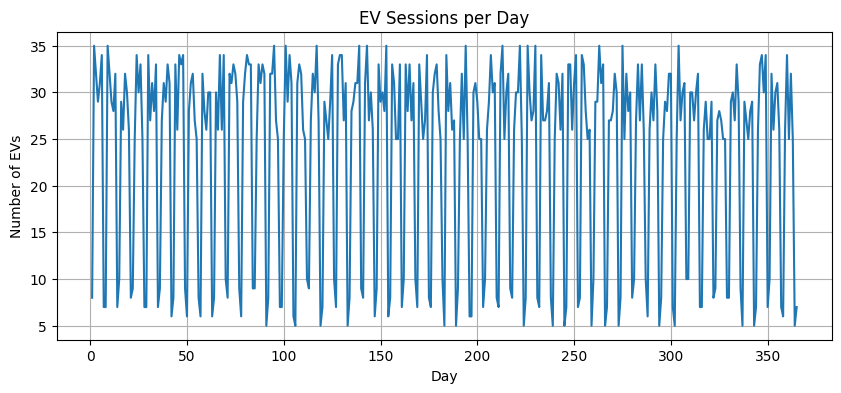

In [64]:
import matplotlib.pyplot as plt

ev_per_day = ev.groupby("day").size()

plt.figure(figsize=(10,4))
plt.plot(ev_per_day)
plt.xlabel("Day")
plt.ylabel("Number of EVs")
plt.title("EV Sessions per Day")
plt.grid()
plt.show()

How long are vehicles actually connected?

In [65]:
ev["parking_duration_h"] = (
    ev["disconnection_minute"] - ev["connection_minute"]
) / 60

ev["parking_duration_h"].describe()

count    8530.000000
mean        7.119267
std         2.357097
min         0.483333
25%         5.366667
50%         7.550000
75%         8.850000
max        16.000000
Name: parking_duration_h, dtype: float64

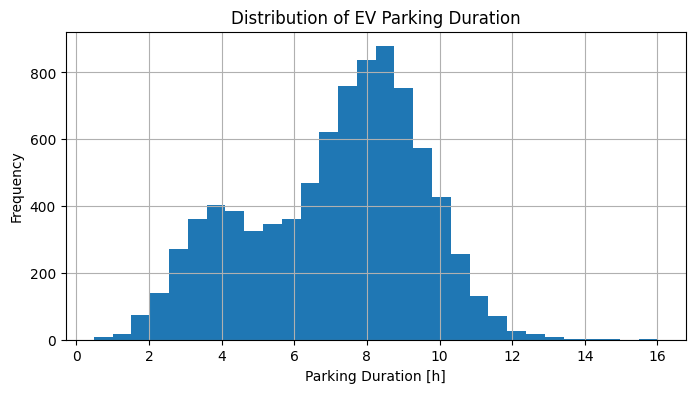

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(ev["parking_duration_h"], bins=30)
plt.xlabel("Parking Duration [h]")
plt.ylabel("Frequency")
plt.title("Distribution of EV Parking Duration")
plt.grid()
plt.show()
# Note that if the vehilce stays 2 hours, there would not be any flexibility, but not the same for 8 and 12 hours situation.

Charging required duration

In [67]:
ev["charging_duration_h"] = (
    ev["full_minute"] - ev["connection_minute"]
) / 60

ev["charging_duration_h"].describe()

count    8530.000000
mean        3.882792
std         2.110050
min         0.050000
25%         2.283333
50%         3.500000
75%         4.916667
max        15.783333
Name: charging_duration_h, dtype: float64

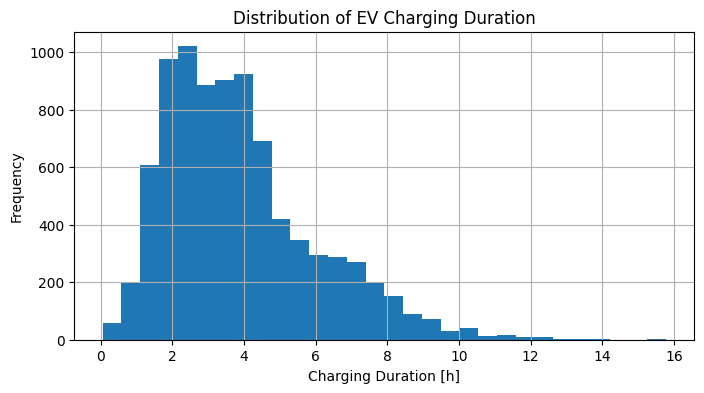

In [68]:
plt.figure(figsize=(8,4))
plt.hist(ev["charging_duration_h"], bins=30)
plt.xlabel("Charging Duration [h]")
plt.ylabel("Frequency")
plt.title("Distribution of EV Charging Duration")
plt.grid()
plt.show()

| Metric  | Parking Time | Charging Time |
| ------- | ------------ | ------------- |
| Mean    | 7.12 h       | 3.88 h        |
| Median  | 7.55 h       | 3.50 h        |
| Maximum | 16.0 h       | 15.78 h       |


Computing the flexibility directly

In [69]:
ev["flexibility_h"] = (
    ev["parking_duration_h"]
    - ev["charging_duration_h"]
)

ev["flexibility_h"].describe()

count    8530.000000
mean        3.236475
std         2.261753
min         0.016667
25%         1.383333
50%         2.916667
75%         4.883333
max        13.166667
Name: flexibility_h, dtype: float64

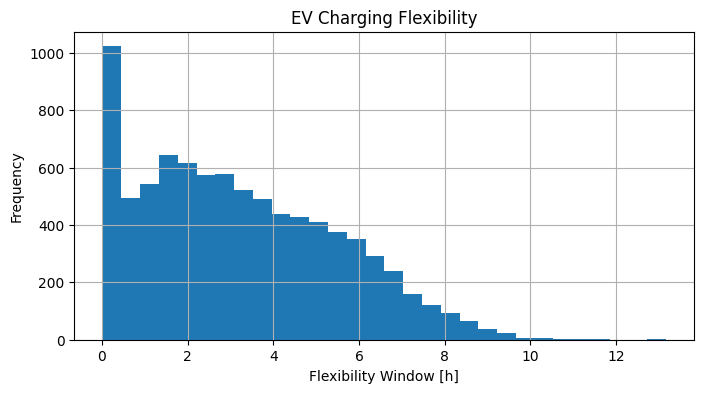

In [70]:
plt.figure(figsize=(8,4))
plt.hist(ev["flexibility_h"], bins=30)
plt.xlabel("Flexibility Window [h]")
plt.ylabel("Frequency")
plt.title("EV Charging Flexibility")
plt.grid()
plt.show()

Flexibility Window=tdeparture​−tarrival​−trequired charge​ ~ This is the resource the EVs act as a battery, without discharge

Inputs Building load = Pload​(t)

In [71]:
load["scaled_power_kw"]

0        7.334217
1        7.284518
2        6.109935
3        6.081038
4        6.380343
          ...    
8755    15.699179
8756    16.758571
8757    15.270208
8758    12.612176
8759     8.762335
Name: scaled_power_kw, Length: 8760, dtype: float64

Availability window:
t_i-arr
t_i-dep

Decision Varible  ~ PEV,i​(t)

Constraint 1
No charging before arrival:   PEV,i​(t)=0
for t < t_i-arr​

Constraint 2
No charging after departure:   PEV,i​(t)=0
for t > t_i-dep

Constraint 3
Energy requirement must be satisfied:

∑_t P_EV,i(t)Δt=Ei	​


Constraint 4
Charging power limit:   0 ≤ PEV,i​(t) ≤ P_charger​

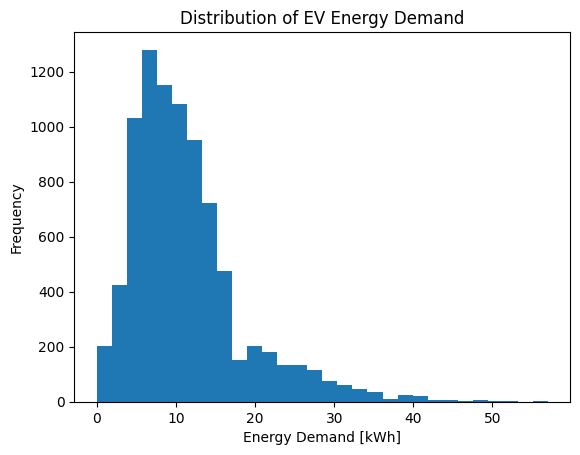

In [72]:
ev["energy_kwh"].hist(bins=30)
plt.xlabel("Energy Demand [kWh]")
plt.ylabel("Frequency")
plt.title("Distribution of EV Energy Demand")
plt.grid()
plt.show()

In [73]:
ev["energy_kwh"].sum()

np.float64(95663.0)

So the EV fleet requires approximately : 95.7 MWh/yr     ~ energy How much energy the cars require to charge mostly 5-15 kWh 

Simulation Horizon.

In [75]:
print(load["timestamp"].min())
print(load["timestamp"].max())

2023-01-01 00:00:00
2023-12-31 23:00:00


In [77]:
len(load)

8760

understand the building demand

In [78]:
load["scaled_power_kw"].describe()

count    8760.000000
mean       10.920434
std         3.862789
min         5.350947
25%         7.794826
50%        10.109365
75%        13.761428
max        25.006348
Name: scaled_power_kw, dtype: float64

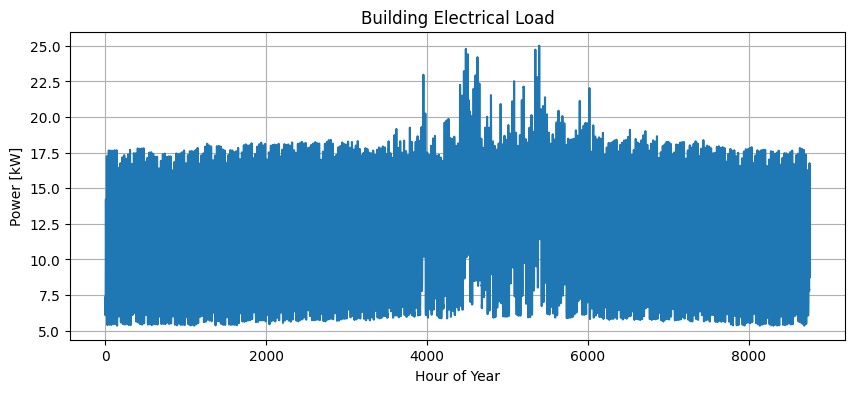

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(load["scaled_power_kw"])
plt.title("Building Electrical Load")
plt.xlabel("Hour of Year")
plt.ylabel("Power [kW]")
plt.grid()
plt.show()

In [81]:
load["scaled_power_kw"].sum() # Annual building energy consumption [kWh]

np.float64(95663.0)

In [82]:
daily_ev_energy = ev.groupby("day")["energy_kwh"].sum()

daily_ev_energy.describe()

count    365.000000
mean     262.090411
std      122.048855
min       37.000000
25%      123.000000
50%      303.000000
75%      355.000000
max      509.000000
Name: energy_kwh, dtype: float64

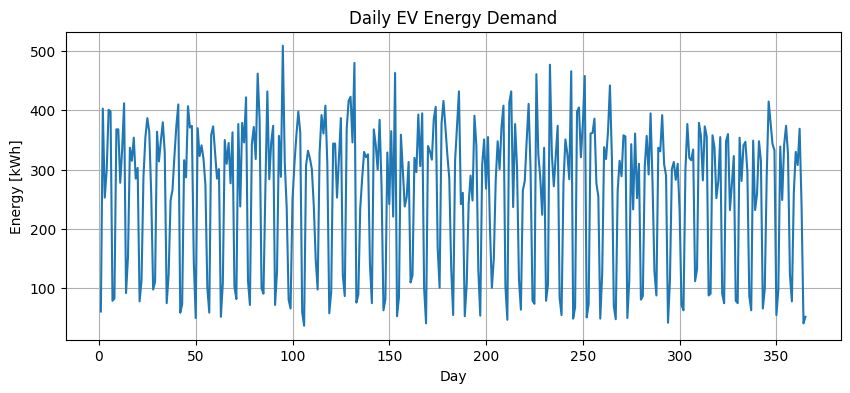

In [84]:
plt.figure(figsize=(10,4))
plt.plot(daily_ev_energy)
plt.title("Daily EV Energy Demand")
plt.xlabel("Day")
plt.ylabel("Energy [kWh]")
plt.grid()
plt.show()
# the mean < median, The periodic dips show that weekends very few EVs arrive.

Optimization Goal

Decision variable:
P_EV(t)

EV charging power assigned to vehicles at time t.

Objective:
Minimize the peak power imported from the grid.

Grid power:

P_grid(t) =
P_building(t)
+ P_EV(t)
- P_PV(t)

Constraints:

1. Every EV must receive its required energy.

2. Charging can only occur between arrival and departure times.

3. Charging power cannot exceed charger limits.

4. Battery state of charge must remain feasible.

Expected benefit:

By shifting charging from high-load periods to low-load periods, the peak building demand can be reduced without affecting user charging requirements.

In [85]:
print("Number of EV sessions:", len(ev))

print("Average energy per session:",
      ev["energy_kwh"].mean())

print("Total annual EV energy:",
      ev["energy_kwh"].sum())

print("Average building power:",
      load["scaled_power_kw"].mean())

print("Annual building energy:",
      load["scaled_power_kw"].sum())

Number of EV sessions: 8530
Average energy per session: 11.214888628370458
Total annual EV energy: 95663.0
Average building power: 10.920433789954338
Annual building energy: 95663.0


Objective 1: extract EV demand patterns

In [86]:
daily_ev_energy = ev.groupby("day")["energy_kwh"].sum()

low_day = daily_ev_energy.idxmin()
medium_day = (daily_ev_energy - daily_ev_energy.median()).abs().idxmin()
high_day = daily_ev_energy.idxmax()

print("Low-demand day:", low_day, "Energy:", daily_ev_energy.loc[low_day])
print("Medium-demand day:", medium_day, "Energy:", daily_ev_energy.loc[medium_day])
print("High-demand day:", high_day, "Energy:", daily_ev_energy.loc[high_day])

Low-demand day: 106 Energy: 37.0
Medium-demand day: 20 Energy: 303.0
High-demand day: 95 Energy: 509.0


In [87]:
scenario_days = {
    "low": low_day,
    "medium": medium_day,
    "high": high_day
}

scenario_days

{'low': np.int64(106), 'medium': np.int64(20), 'high': np.int64(95)}